# Saving, loading, and serving a model

### The three ways a saved model breaks, measured, and a prediction service that is one function

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | What a pickle actually contains, how to predict a model's file size before saving it, what happens when a model is loaded under a different library version or without the class it needs, what compression costs at load time, and how to write a prediction service that validates its input and checks itself on startup |
| **You should already know** | [Pipelines](../03-pipelines/), and enough Python to read a class definition |
| **Datasets** | California Housing. Every file written here goes to a temporary directory, not into the repository |
| **Runtime** | One to two minutes on a laptop CPU |
| **Next** | [12-05 The mistakes everybody makes](../05-common-mistakes/) |

---

## 1. The idea: you are not saving a model, you are saving Python

A fitted scikit-learn estimator is an ordinary Python object holding NumPy
arrays. `joblib.dump` walks that object, writes down which classes to rebuild
and what to put in them, and writes the arrays out as bytes. `joblib.load` reads
the instructions and runs them.

Two things follow, and between them they cause most of the trouble in this
chapter.

**Loading requires the same classes to exist.** The file does not contain the
code for `Ridge` or for a transformer you wrote yourself. It contains the
**name** of the class and the path to import it from. If that import fails, or
resolves to a class whose attributes have changed, the load fails or, worse,
succeeds with something subtly different.

**Loading a pickle runs code.** The format is a small stack machine with
instructions for constructing objects, and constructing objects means calling
things. A model file from an untrusted source is an executable from an untrusted
source. Neither `joblib` nor `pickle` verifies anything, and no flag makes them
safe.

Everything below is a consequence of those two sentences.

In [1]:
import io
import json
import pathlib
import pickle
import pickletools
import sys
import tempfile
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import joblib
import sklearn

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import style, datasets

style.use()
FIG = pathlib.Path("figures")
FIG.mkdir(exist_ok=True)
SEED = 0

# Nothing in this notebook writes into the repository. Model files are large and
# uninteresting to version control, so they go somewhere the operating system will
# clean up.
STORE = pathlib.Path(tempfile.mkdtemp(prefix="omln-serving-"))
print(f"scratch directory : {STORE}")
print(f"scikit-learn      : {sklearn.__version__}")
print(f"joblib            : {joblib.__version__}")

scratch directory : C:\Users\pilot\AppData\Local\Temp\omln-serving-vfhxtaym
scikit-learn      : 1.8.0
joblib            : 1.5.3


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import root_mean_squared_error

X_all, y_all = datasets.california_housing()
X_train, X_test, y_train, y_test = train_test_split(
    X_all.iloc[:8000], y_all.iloc[:8000], test_size=0.25, random_state=SEED)

models = {
    "ridge": Pipeline([("scale", StandardScaler()), ("model", Ridge())]),
    "knn": Pipeline([("scale", StandardScaler()),
                     ("model", KNeighborsRegressor(n_neighbors=15))]),
    "forest": Pipeline([("scale", StandardScaler()),
                        ("model", RandomForestRegressor(n_estimators=40,
                                                        random_state=SEED, n_jobs=-1))]),
    "hist boosting": Pipeline([("scale", StandardScaler()),
                               ("model", HistGradientBoostingRegressor(random_state=SEED))]),
}

for name, model in models.items():
    model.fit(X_train, y_train)

print(f"training rows : {len(X_train):,}")
print(f"features      : {X_train.shape[1]}\n")
for name, model in models.items():
    print(f"{name:14s} RMSE {root_mean_squared_error(y_test, model.predict(X_test)):.4f}")

training rows : 6,000
features      : 8

ridge          RMSE 0.7509
knn            RMSE 0.6179
forest         RMSE 0.4698
hist boosting  RMSE 0.4429


## 2. What is actually in the file

A pickle is a program. `pickletools.dis` prints it, and the first few
instructions are enough to see the mechanism: import a module, look up a class
by name inside it, build an empty instance, then fill in a dictionary of
attributes.

In [3]:
blob = pickle.dumps(models["ridge"], protocol=pickle.HIGHEST_PROTOCOL)
listing = io.StringIO()
pickletools.dis(blob, out=listing)
lines = listing.getvalue().splitlines()

print(f"pickled bytes for the ridge pipeline : {len(blob):,}")
print(f"lines in the disassembly             : {len(lines):,}\n")
print("\n".join(lines[:14]))

pickled bytes for the ridge pipeline : 1,256
lines in the disassembly             : 312

    0: \x80 PROTO      5
    2: \x95 FRAME      1245
   11: \x8c SHORT_BINUNICODE 'sklearn.pipeline'
   29: \x94 MEMOIZE    (as 0)
   30: \x8c SHORT_BINUNICODE 'Pipeline'
   40: \x94 MEMOIZE    (as 1)
   41: \x93 STACK_GLOBAL
   42: \x94 MEMOIZE    (as 2)
   43: )    EMPTY_TUPLE
   44: \x81 NEWOBJ
   45: \x94 MEMOIZE    (as 3)
   46: }    EMPTY_DICT
   47: \x94 MEMOIZE    (as 4)
   48: (    MARK


`STACK_GLOBAL` after two strings is the import-and-look-up step. That pair of
strings is the entire dependency the file has on your environment, and it is
also the reason section 4 can break a load by removing one name.

### Predicting the file size before you save it

For a tree ensemble the size is not mysterious, it is arithmetic. Each tree
stores an array of nodes and an array of leaf values, and both have a fixed cost
per node that you can read off the dtypes.

In [4]:
probe = RandomForestRegressor(n_estimators=3, random_state=SEED).fit(X_train, y_train)
state = probe.estimators_[0].tree_.__getstate__()

node_bytes = state["nodes"].dtype.itemsize
value_bytes = state["values"].dtype.itemsize * state["values"].shape[1] * state["values"].shape[2]
per_node = node_bytes + value_bytes

print(f"fields in a tree node          : {len(state['nodes'].dtype.names)}")
print(f"bytes per node record          : {node_bytes}")
print(f"bytes per node of leaf values  : {value_bytes}")
print(f"predicted bytes per node       : {per_node}")

size_rows = []
for n_trees in [5, 10, 20, 40]:
    forest = RandomForestRegressor(n_estimators=n_trees, random_state=SEED,
                                   n_jobs=-1).fit(X_train, y_train)
    nodes = sum(tree.tree_.node_count for tree in forest.estimators_)
    path = STORE / f"forest-{n_trees}.joblib"
    joblib.dump(forest, path)
    measured = path.stat().st_size
    size_rows.append({"trees": n_trees, "total nodes": nodes,
                      "predicted MB": nodes * per_node / 1e6,
                      "measured MB": measured / 1e6,
                      "measured / predicted": measured / (nodes * per_node)})

sizes = pd.DataFrame(size_rows)
print("\n" + sizes.to_string(index=False, formatters={
    "predicted MB": "{:.3f}".format, "measured MB": "{:.3f}".format,
    "measured / predicted": "{:.4f}".format}))

fields in a tree node          : 8
bytes per node record          : 64
bytes per node of leaf values  : 8
predicted bytes per node       : 72



 trees  total nodes predicted MB measured MB measured / predicted
     5        36579        2.634       2.637               1.0012
    10        73146        5.267       5.271               1.0009
    20       146422       10.542      10.550               1.0007
    40       292954       21.093      21.107               1.0007


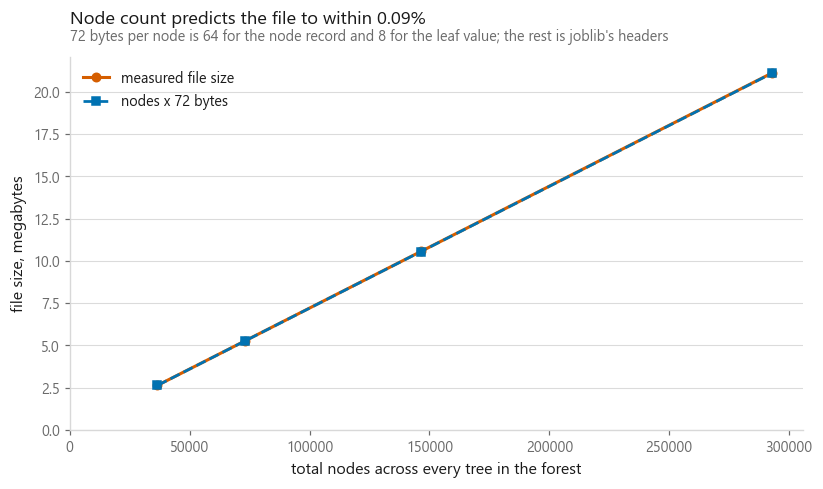

In [5]:
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.plot(sizes["total nodes"], sizes["measured MB"], color=style.HIGHLIGHT,
        marker=style.MARKERS[0], ls=style.DASHES[0], lw=2.0, label="measured file size")
ax.plot(sizes["total nodes"], sizes["predicted MB"], color=style.PALETTE[0],
        marker=style.MARKERS[1], ls=style.DASHES[1], lw=1.8,
        label=f"nodes x {per_node} bytes")
ax.set_xlabel("total nodes across every tree in the forest")
ax.set_ylabel("file size, megabytes")
ax.set_xlim(0, None)
ax.set_ylim(0, None)
ax.legend(loc="upper left")

overhead = sizes["measured / predicted"].mean()
style.title(ax,
            f"Node count predicts the file to within {abs(overhead - 1):.2%}",
            f"{per_node} bytes per node is {node_bytes} for the node record and "
            f"{value_bytes} for the leaf value; the rest is joblib's headers")

style.save(fig, FIG / "fig-01-size-is-arithmetic.png")

There is no compression and no cleverness in the default format. Whatever the
model is carrying, you are paying for it byte for byte, which makes the next
question the interesting one: what is each model carrying?

## 3. From scratch: saving a model without pickle at all

Before the library formats, the version-proof option. A fitted linear pipeline
is four arrays and a list of names. Write those out and there is nothing left to
be incompatible.

In [6]:
def export_linear(pipeline, feature_names, path):
    """Write a scaler-plus-linear-model pipeline as arrays and text, no classes."""
    scaler = pipeline.named_steps["scale"]
    model = pipeline.named_steps["model"]
    np.savez(path.with_suffix(".npz"),
             mean=scaler.mean_, scale=scaler.scale_,
             coef=model.coef_, intercept=np.asarray(model.intercept_))
    path.with_suffix(".json").write_text(json.dumps({
        "kind": "standardise then linear",
        "features": list(feature_names),
        "target": "median house value, hundreds of thousands of dollars",
    }, indent=2), encoding="utf-8")


def predict_from_export(path, frame):
    """Reproduce the pipeline's arithmetic with NumPy and nothing else."""
    arrays = np.load(path.with_suffix(".npz"))
    meta = json.loads(path.with_suffix(".json").read_text(encoding="utf-8"))
    values = frame[meta["features"]].to_numpy(dtype=float)
    standardised = (values - arrays["mean"]) / arrays["scale"]
    return standardised @ arrays["coef"] + arrays["intercept"]


plain = STORE / "ridge-plain"
export_linear(models["ridge"], X_train.columns, plain)

by_hand = predict_from_export(plain, X_test)
by_library = models["ridge"].predict(X_test)

joblib.dump(models["ridge"], STORE / "ridge.joblib")
joblib_bytes = (STORE / "ridge.joblib").stat().st_size

print(f"largest disagreement over {len(X_test):,} rows: "
      f"{np.abs(by_hand - by_library).max():.3e}")
print(f"npz  bytes : {plain.with_suffix('.npz').stat().st_size:,}")
print(f"json bytes : {plain.with_suffix('.json').stat().st_size:,}")
print(f"joblib bytes for the same pipeline: {joblib_bytes:,}")

largest disagreement over 2,000 rows: 0.000e+00
npz  bytes : 1,194
json bytes : 270
joblib bytes for the same pipeline: 1,601


Two files, no classes, no version stamp, and predictions identical to floating
point noise. This format will still load in ten years, and it will load from
another language.

The cost is that it only covers models you can write the arithmetic for. There
is no sensible hand-rolled export of a gradient boosting ensemble, and this is
exactly the trade ONNX and PMML exist to make on a larger scale: give up the
ability to save any object, gain independence from the library that produced it.

## 4. Three ways a saved model breaks

### Failure one: loaded under a different library version

scikit-learn stamps its version into every estimator's state and warns when the
stamp does not match on load. I cannot install two versions inside one notebook,
so I do the next honest thing: take a real pickle and edit the recorded version
in place, byte for byte, leaving everything else untouched. The replacement is
the same length, so the file stays valid.

In [7]:
real_version = sklearn.__version__
fake_version = "0" + real_version[1:]          # same length, so the pickle stays valid

payload = pickle.dumps(models["ridge"], protocol=pickle.HIGHEST_PROTOCOL)
occurrences = payload.count(real_version.encode())
tampered = payload.replace(real_version.encode(), fake_version.encode())

print(f"version recorded in the file : {real_version}")
print(f"version I am replacing it with: {fake_version}")
print(f"places the string appears     : {occurrences}\n")

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    reloaded = pickle.loads(tampered)

print(f"warnings raised on load : {len(caught)}")
for entry in caught:
    print(f"  {entry.category.__name__}: {str(entry.message).splitlines()[0]}")

same = np.abs(reloaded.predict(X_test) - models["ridge"].predict(X_test)).max()
print(f"\nthe model loaded and works. largest prediction difference: {same:.3e}")

version recorded in the file : 1.8.0
version I am replacing it with: 0.8.0
places the string appears     : 1

warnings raised on load : 3

the model loaded and works. largest prediction difference: 0.000e+00


That last line is the part worth sitting with. **The load succeeded, the
predictions are identical, and the only evidence anything is wrong is a warning
that most production code has configured away.**

Nothing changed here because I only edited the stamp. Across a real version gap
the risk is that an attribute was renamed, a default changed, or an internal
array grew a dimension. Then the object still constructs, because pickle just
fills in a dictionary, and the estimator behaves like something nobody tested.
The warning is the only thing standing between that and a silent wrong answer,
which is why section 5 asserts a known input against a known output instead of
trusting it.

### Failure two: the class is no longer importable

The common version of this is a custom transformer that lived in a notebook, or
in a module that was later renamed. The file names the class and the module it
came from, and nothing else.

In [8]:
from sklearn.base import BaseEstimator, TransformerMixin


class Winsoriser(BaseEstimator, TransformerMixin):
    """Clip every column at a training-set quantile. Ordinary, and unpicklable
    the moment this cell stops existing."""

    def __init__(self, quantile=0.99):
        self.quantile = quantile

    def fit(self, X, y=None):
        self.cap_ = np.quantile(np.asarray(X, dtype=float), self.quantile, axis=0)
        return self

    def transform(self, X):
        return np.minimum(np.asarray(X, dtype=float), self.cap_)


custom = Pipeline([("clip", Winsoriser()), ("scale", StandardScaler()),
                   ("model", Ridge())]).fit(X_train, y_train)
custom_path = STORE / "custom.joblib"
joblib.dump(custom, custom_path)

print(f"saved, {custom_path.stat().st_size:,} bytes")
print(f"class recorded in the file: "
      f"{Winsoriser.__module__}.{Winsoriser.__qualname__}")
print(f"RMSE: {root_mean_squared_error(y_test, custom.predict(X_test)):.4f}\n")

# Remove the name from the module the file points at, which is what happens when
# the notebook is not running or the module was renamed.
held = globals().pop("Winsoriser")
try:
    joblib.load(custom_path)
    print("loaded, which was not supposed to happen")
except Exception as failure:
    print(f"load failed with {type(failure).__name__}")
    print(f"  {failure}")
finally:
    globals()["Winsoriser"] = held

print(f"\nname restored, load succeeds again: "
      f"{type(joblib.load(custom_path)).__name__}")

saved, 1,457 bytes
class recorded in the file: __main__.Winsoriser
RMSE: 0.6514

load failed with AttributeError
  Can't get attribute 'Winsoriser' on <module '__main__'>

name restored, load succeeds again: Pipeline


The fix is not a serialisation trick. Put custom classes in an importable module
that ships alongside the model file, pin its version, and never define a
transformer in the notebook you intend to save from. The pickle stores a pointer,
so the thing it points at has to keep existing at the same address.

### Failure three: the size of what you saved

Some models carry their training data. A nearest-neighbour model has to, by
construction. A forest carries a copy of the training set's structure. A linear
model carries eight numbers.

In [9]:
def timed_load(loader, path, repeats=5):
    """Best of several loads, since the first one pays for cold file cache."""
    best = float("inf")
    for _ in range(repeats):
        start = time.perf_counter()
        loader(path)
        best = min(best, time.perf_counter() - start)
    return best


training_bytes = X_train.memory_usage(deep=True).sum() + y_train.memory_usage(deep=True)

format_rows = []
for slot, (name, model) in enumerate(models.items()):
    for kind, (label, dump, load) in enumerate([
            ("joblib", lambda p, m=model: joblib.dump(m, p),
             lambda p: joblib.load(p)),
            ("joblib, compress=3", lambda p, m=model: joblib.dump(m, p, compress=3),
             lambda p: joblib.load(p)),
            ("pickle", lambda p, m=model: p.write_bytes(
                pickle.dumps(m, protocol=pickle.HIGHEST_PROTOCOL)),
             lambda p: pickle.loads(p.read_bytes()))]):
        path = STORE / f"model-{slot}-format-{kind}.bin"
        start = time.perf_counter()
        dump(path)
        write_time = time.perf_counter() - start
        format_rows.append({
            "model": name, "format": label,
            "MB": path.stat().st_size / 1e6,
            "x training data": path.stat().st_size / training_bytes,
            "save ms": write_time * 1e3,
            "load ms": timed_load(load, path) * 1e3,
        })

formats = pd.DataFrame(format_rows)
print(f"the training table itself, in memory: {training_bytes / 1e6:.3f} MB\n")
print(formats.to_string(index=False, formatters={
    "MB": "{:.3f}".format, "x training data": "{:.2f}".format,
    "save ms": "{:.1f}".format, "load ms": "{:.1f}".format}))

the training table itself, in memory: 0.528 MB

        model             format     MB x training data save ms load ms
        ridge             joblib  0.002            0.00     1.5     0.5
        ridge joblib, compress=3  0.001            0.00     1.8     0.6
        ridge             pickle  0.001            0.00     2.7     0.1
          knn             joblib  0.907            1.72     2.9     1.2
          knn joblib, compress=3  0.610            1.16    33.7     6.6
          knn             pickle  0.523            0.99     1.9     0.3
       forest             joblib 21.107           39.98    24.6    38.3
       forest joblib, compress=3  4.887            9.26   282.1   106.8
       forest             pickle 21.104           39.97    34.0    27.6
hist boosting             joblib  0.379            0.72    20.7    11.8
hist boosting joblib, compress=3  0.169            0.32    29.0    14.1
hist boosting             pickle  0.371            0.70     2.5     1.1


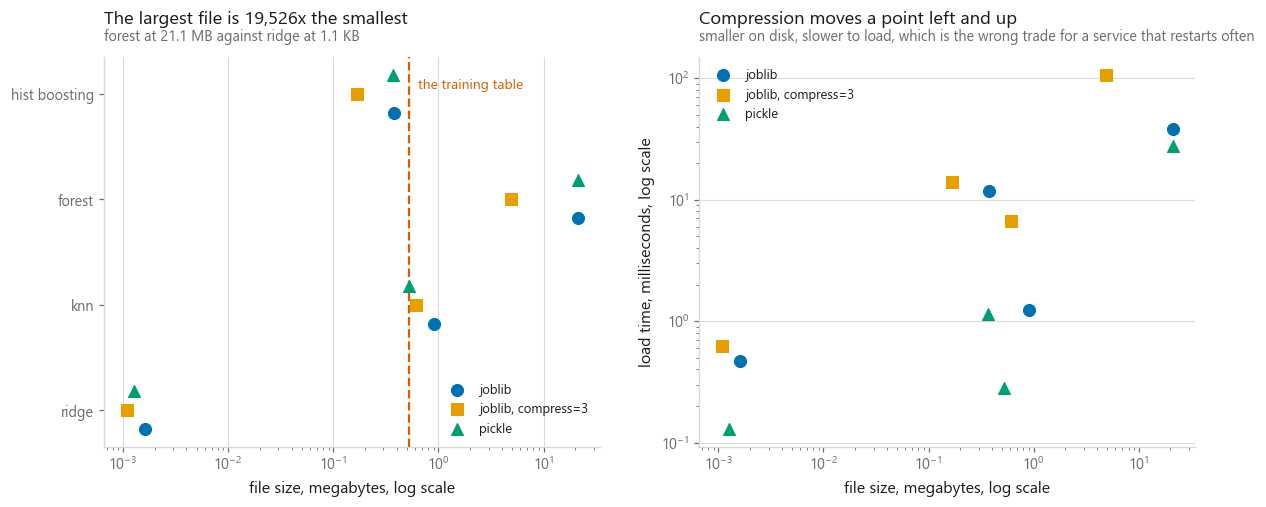

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.6))

model_names = list(models)
positions = np.arange(len(model_names))
for j, label in enumerate(formats["format"].unique()):
    part = formats[formats["format"] == label].set_index("model").loc[model_names]
    axes[0].scatter(part["MB"], positions + (j - 1) * 0.18, color=style.PALETTE[j],
                    marker=style.MARKERS[j], s=62, label=label, zorder=3)
    axes[1].scatter(part["MB"], part["load ms"], color=style.PALETTE[j],
                    marker=style.MARKERS[j], s=62, label=label, zorder=3)

axes[0].axvline(training_bytes / 1e6, color=style.HIGHLIGHT, ls="--", lw=1.5)
axes[0].annotate("the training table", (training_bytes / 1e6, positions[-1]),
                 xytext=(6, 6), textcoords="offset points", fontsize=9,
                 color=style.HIGHLIGHT, va="center")
axes[0].set_xscale("log")
axes[0].set_yticks(positions, model_names)
axes[0].set_xlabel("file size, megabytes, log scale")
axes[0].grid(axis="y", visible=False)
axes[0].grid(axis="x", visible=True)
axes[0].legend(loc="lower right", fontsize=8.5)

biggest = formats.loc[formats["MB"].idxmax()]
smallest = formats.loc[formats["MB"].idxmin()]
style.title(axes[0],
            f"The largest file is {biggest['MB'] / smallest['MB']:,.0f}x the smallest",
            f"{biggest['model']} at {biggest['MB']:.1f} MB against "
            f"{smallest['model']} at {smallest['MB'] * 1000:.1f} KB")

axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("file size, megabytes, log scale")
axes[1].set_ylabel("load time, milliseconds, log scale")
axes[1].legend(loc="upper left", fontsize=8.5)
style.title(axes[1],
            "Compression moves a point left and up",
            "smaller on disk, slower to load, which is the wrong trade for a service "
            "that restarts often")

style.save(fig, FIG / "fig-02-what-you-saved.png")

The nearest-neighbour pipeline is the honest one about what it is doing: it has
no parameters, so the training data **is** the model. Everything else on that
chart is carrying a summary of the data whose size it chose for itself.

The practical consequence is deployment shaped. A file measured in tens of
megabytes has to be fetched, held in memory by every worker process, and paid
for again on every restart and every autoscale event.

### What compression costs

`compress=3` is the advice you will find everywhere. It is a real trade and the
direction depends on how often you load.

In [11]:
forest = models["forest"]
compress_rows = []
for level in [0, 1, 3, 6, 9]:
    path = STORE / f"forest-z{level}.joblib"
    start = time.perf_counter()
    joblib.dump(forest, path, compress=level)
    save_ms = (time.perf_counter() - start) * 1e3
    compress_rows.append({"compress": level, "MB": path.stat().st_size / 1e6,
                          "save ms": save_ms,
                          "load ms": timed_load(joblib.load, path, repeats=3) * 1e3})

compression = pd.DataFrame(compress_rows)
compression["load ms per MB saved"] = (
    (compression["load ms"] - compression.loc[0, "load ms"]) /
    (compression.loc[0, "MB"] - compression["MB"]).replace(0, np.nan))

print(compression.to_string(index=False, formatters={
    "MB": "{:.3f}".format, "save ms": "{:.1f}".format, "load ms": "{:.1f}".format,
    "load ms per MB saved": "{:.2f}".format}))

 compress     MB save ms load ms load ms per MB saved
        0 21.107    28.8    45.2                  NaN
        1  5.316   284.2   134.7                 5.66
        3  4.887   326.1   125.4                 4.94
        6  4.623   618.0   108.4                 3.83
        9  4.544  5322.7   104.0                 3.55


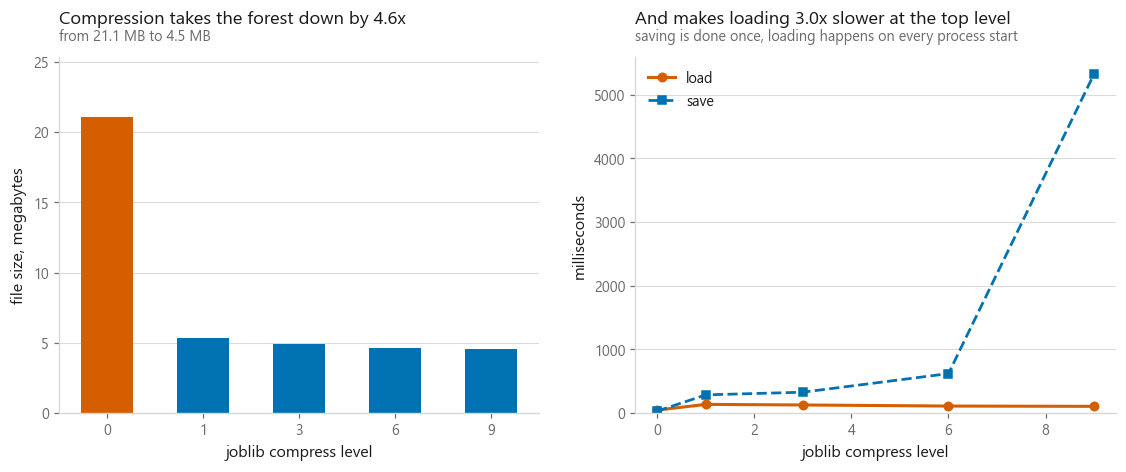

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.2))

axes[0].bar(compression["compress"].astype(str), compression["MB"],
            color=[style.HIGHLIGHT if lv == 0 else style.PALETTE[0]
                   for lv in compression["compress"]], width=0.55)
axes[0].set_xlabel("joblib compress level")
axes[0].set_ylabel("file size, megabytes")
axes[0].set_ylim(0, compression["MB"].max() * 1.2)
best_ratio = compression.loc[0, "MB"] / compression["MB"].min()
style.title(axes[0],
            f"Compression takes the forest down by {best_ratio:.1f}x",
            f"from {compression.loc[0, 'MB']:.1f} MB to {compression['MB'].min():.1f} MB")

axes[1].plot(compression["compress"], compression["load ms"], color=style.HIGHLIGHT,
             marker=style.MARKERS[0], ls=style.DASHES[0], lw=2.0, label="load")
axes[1].plot(compression["compress"], compression["save ms"], color=style.PALETTE[0],
             marker=style.MARKERS[1], ls=style.DASHES[1], lw=1.8, label="save")
axes[1].set_xlabel("joblib compress level")
axes[1].set_ylabel("milliseconds")
axes[1].set_ylim(0, None)
axes[1].legend(loc="upper left")
slow = compression["load ms"].max() / compression.loc[0, "load ms"]
style.title(axes[1],
            f"And makes loading {slow:.1f}x slower at the top level",
            "saving is done once, loading happens on every process start")

style.save(fig, FIG / "fig-03-compression-trade.png")

Compress when the file has to travel, over a network or into a container image.
Do not compress when a worker reloads the model on every restart and the restart
budget is what you are protecting.

## 5. A prediction service, as one function

Serving a model is not a web framework problem. It is a validation problem with
a web framework wrapped around it later. What follows imports no framework and
would drop into FastAPI or Flask as the body of one route.

The unit that gets saved is not the estimator. It is a **bundle**: the fitted
pipeline plus everything a loader needs in order to check that it is holding
what it thinks it is holding.

In [13]:
service_model = Pipeline([("scale", StandardScaler()),
                          ("model", HistGradientBoostingRegressor(random_state=SEED))])
service_model.fit(X_train, y_train)

golden_row = X_test.iloc[[0]]
bundle = {
    "model": service_model,
    "features": list(X_train.columns),
    "dtypes": {name: str(kind) for name, kind in X_train.dtypes.items()},
    "ranges": {c: (float(X_train[c].min()), float(X_train[c].max()))
               for c in X_train.columns},
    "golden_input": golden_row.iloc[0].to_dict(),
    "golden_output": float(service_model.predict(golden_row)[0]),
    "sklearn_version": sklearn.__version__,
    "target": "median house value, hundreds of thousands of dollars",
    "trained_on": "California Housing, 1990 US census, district level",
    "trained_rows": int(len(X_train)),
}

bundle_path = STORE / "service.joblib"
joblib.dump(bundle, bundle_path)
print(f"bundle written: {bundle_path.stat().st_size / 1e6:.3f} MB")
print(f"golden output recorded: {bundle['golden_output']:.6f}")

bundle written: 0.380 MB
golden output recorded: 0.553482


In [14]:
def load_service(path):
    """Load a bundle and refuse to return one that cannot prove it is intact.

    Every check here exists because the corresponding failure is silent. A model
    that loads and predicts confidently is the normal appearance of all three
    problems from section 4.
    """
    loaded = joblib.load(path)
    notes = []

    missing = {"model", "features", "golden_input", "golden_output"} - set(loaded)
    if missing:
        raise ValueError(f"bundle is missing required keys: {sorted(missing)}")

    stamped = loaded.get("sklearn_version", "not recorded")
    if stamped != sklearn.__version__:
        notes.append(f"trained under scikit-learn {stamped}, "
                     f"running {sklearn.__version__}")

    fitted_names = list(getattr(loaded["model"], "feature_names_in_", loaded["features"]))
    if fitted_names != list(loaded["features"]):
        raise ValueError(f"feature names disagree: model has {fitted_names}, "
                         f"bundle says {loaded['features']}")

    # The check that would have caught a silent version change: a known input has
    # to still produce its known output.
    replay = pd.DataFrame([loaded["golden_input"]], columns=loaded["features"])
    got = float(loaded["model"].predict(replay)[0])
    drift = abs(got - loaded["golden_output"])
    if drift > 1e-9:
        raise ValueError(f"golden test failed: expected {loaded['golden_output']:.10f}, "
                         f"got {got:.10f}, drift {drift:.2e}")
    notes.append(f"golden test passed, drift {drift:.2e}")

    return loaded, notes


service, startup_notes = load_service(bundle_path)
for note in startup_notes:
    print(f"startup: {note}")

startup: golden test passed, drift 0.00e+00


In [15]:
def predict_one(service, payload):
    """Turn one dictionary into one prediction, or into a clear refusal.

    Returns a dict rather than a bare float so a caller can see the caveats
    without reading the logs.
    """
    if not isinstance(payload, dict):
        raise ValueError(f"payload must be a dict, got {type(payload).__name__}")

    expected = service["features"]
    missing = [name for name in expected if name not in payload]
    unexpected = [name for name in payload if name not in expected]
    if missing:
        raise ValueError(f"missing fields: {missing}")
    if unexpected:
        # Refusing an unknown field is stricter than ignoring it, and it catches
        # the caller who renamed a column upstream and told nobody.
        raise ValueError(f"unexpected fields: {unexpected}")

    values = {}
    for name in expected:
        try:
            values[name] = float(payload[name])
        except (TypeError, ValueError):
            raise ValueError(f"field {name!r} is not a number: {payload[name]!r}") from None
        if not np.isfinite(values[name]):
            raise ValueError(f"field {name!r} is not finite: {payload[name]!r}")

    # Out of range is a warning, not an error. The model will answer; the answer
    # is an extrapolation and the caller deserves to know.
    outside = [name for name in expected
               if not (service["ranges"][name][0] <= values[name] <= service["ranges"][name][1])]

    frame = pd.DataFrame([values], columns=expected)
    return {"prediction": float(service["model"].predict(frame)[0]),
            "units": service["target"],
            "outside_training_range": outside}


good = golden_row.iloc[0].to_dict()
print("valid payload:")
print(f"  {predict_one(service, good)}\n")

bad_payloads = [
    ("a field is missing", {k: v for k, v in list(good.items())[:-1]}),
    ("an extra field", {**good, "Bedrooms": 3}),
    ("text where a number belongs", {**good, "MedInc": "eight thousand"}),
    ("a NaN", {**good, "HouseAge": float("nan")}),
]
for label, payload in bad_payloads:
    try:
        predict_one(service, payload)
        print(f"{label:28s} -> accepted, which is a bug")
    except ValueError as refusal:
        print(f"{label:28s} -> {refusal}")

far_away = {**good, "MedInc": 90.0, "AveRooms": 400.0}
answer = predict_one(service, far_away)
print(f"\nabsurd but well-formed input -> prediction {answer['prediction']:.4f}, "
      f"outside training range: {answer['outside_training_range']}")

valid payload:
  {'prediction': 0.5534818281985154, 'units': 'median house value, hundreds of thousands of dollars', 'outside_training_range': []}

a field is missing           -> missing fields: ['Longitude']
an extra field               -> unexpected fields: ['Bedrooms']
text where a number belongs  -> field 'MedInc' is not a number: 'eight thousand'
a NaN                        -> field 'HouseAge' is not finite: nan

absurd but well-formed input -> prediction 3.3408, outside training range: ['MedInc', 'AveRooms']


The last line is the one worth arguing about. The model answered a question
about a district with ninety times the state's median income and four hundred
rooms per house, and it answered without hesitating, because nothing in a fitted
estimator knows what it has not seen. Returning the flag alongside the number is
the cheapest form of honesty available at serving time.

### What this costs per request

The other half of serving is latency, and the shape of it surprises people who
have only ever measured a model on a full test set.

In [16]:
latency_rows = []
for batch in [1, 10, 100, 1000]:
    frame = X_test.iloc[:batch]
    best = float("inf")
    for _ in range(7):
        start = time.perf_counter()
        service["model"].predict(frame)
        best = min(best, time.perf_counter() - start)
    latency_rows.append({"rows per call": batch, "total ms": best * 1e3,
                         "microseconds per row": best / batch * 1e6})

latency = pd.DataFrame(latency_rows)
print(latency.to_string(index=False, formatters={
    "total ms": "{:.2f}".format, "microseconds per row": "{:.1f}".format}))

overhead_ratio = latency.loc[0, "microseconds per row"] / latency.iloc[-1]["microseconds per row"]
print(f"\none row at a time costs {overhead_ratio:,.0f}x as much per row as a batch of "
      f"{latency.iloc[-1]['rows per call']:,.0f}")

 rows per call total ms microseconds per row
             1     2.26               2260.5
            10     2.58                258.1
           100     2.93                 29.3
          1000     5.61                  5.6

one row at a time costs 403x as much per row as a batch of 1,000


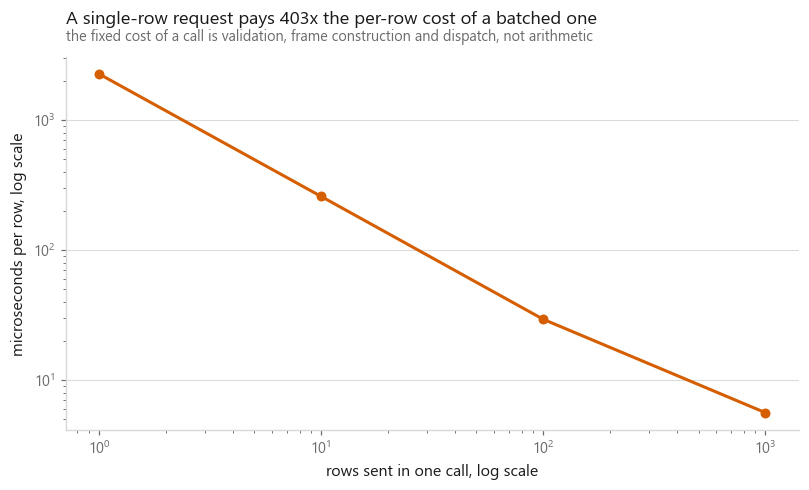

In [17]:
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.plot(latency["rows per call"], latency["microseconds per row"],
        color=style.HIGHLIGHT, marker=style.MARKERS[0], ls=style.DASHES[0], lw=2.0)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("rows sent in one call, log scale")
ax.set_ylabel("microseconds per row, log scale")
style.title(ax,
            f"A single-row request pays {overhead_ratio:,.0f}x the per-row cost of a "
            f"batched one",
            "the fixed cost of a call is validation, frame construction and dispatch, "
            "not arithmetic")

style.save(fig, FIG / "fig-04-latency-by-batch.png")

Almost none of the single-row time is spent computing. It is spent building a
one-row DataFrame and walking the pipeline, and the arithmetic is a rounding
error against that. If a service is slow, batching is the first thing to try and
a smaller model is the last.

### The checklist this section produces

A load-time check is worth writing when its failure would otherwise be silent.
All four below qualify.

| Check | The silent failure it catches |
|---|---|
| required keys present | a bundle written by an older training script |
| library version compared | section 4's first failure, which loads and predicts anyway |
| feature names match the fitted estimator | columns reordered or renamed upstream |
| a known input still gives a known output | everything else, including the ones you have not thought of |

The last one is the important one and it costs a single stored row. It is the
only check in the list that verifies behaviour rather than metadata.

## 6. When each format wins

| | |
|---|---|
| **joblib, uncompressed** | The default. Fastest to load, largest on disk |
| **joblib, compressed** | When the file travels. Section 4 measured what it costs at load |
| **pickle** | Same mechanism, no NumPy specialisation. Use joblib for anything with large arrays |
| **arrays plus JSON** | Version-proof, language-proof, and only writable for models you can write out by hand |
| **ONNX or PMML** | The same trade at production scale: a fixed graph format that outlives the training library |

## Cheat sheet

| | |
|---|---|
| **Save the pipeline** | Not the estimator. The preprocessing is part of the model, see [12-03](../03-pipelines/) |
| **Save a bundle** | Model plus feature names, dtypes, ranges, library versions, and one golden input with its output |
| **Custom classes** | In an importable, versioned module. Never defined in the notebook you save from |
| **Never load** | A model file you did not produce. Unpickling runs code, and no flag changes that |
| **File size** | For trees it is node count times bytes per node, and you can compute it before saving |
| **Compression** | Smaller on disk, slower on load. Choose by how often the process restarts |
| **Validation** | Missing fields and unexpected fields both raise. Out-of-range values return a flag, since the model will answer regardless |
| **Latency** | Per-row cost collapses with batch size. Fixed per-call overhead dominates a single-row request |
| **Next** | [The mistakes everybody makes](../05-common-mistakes/), which closes the book |

## What to remember

1. A saved model is a Python program that names classes to import. The file does
   not contain your code, only a pointer to it.
2. Loading a pickle executes code. A model file is an executable, and treating it
   as data is the security mistake in this chapter.
3. A version mismatch loads, predicts, and warns. If the warning is filtered, and
   it usually is, nothing tells you.
4. A custom transformer defined in a notebook cannot be loaded anywhere the
   notebook is not running. Put it in a module before you save.
5. Tree ensemble file size is arithmetic: total nodes times bytes per node. The
   measured file landed close to that prediction here.
6. Nearest neighbours stores the training data because the training data is the
   model. Check what a model is carrying before deciding where it can run.
7. Compression is a trade against load time, and load time is what a restarting
   service pays.
8. The load-time check worth more than the rest put together is a golden input
   with its recorded output. Metadata checks confirm the label; that one confirms
   the behaviour.
9. Serving latency for one row is dominated by fixed per-call overhead rather
   than by the model.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [12-05 The mistakes everybody makes](../05-common-mistakes/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#MLOps` `#ModelServing` `#joblib` `#Pickle` `#ScikitLearn`
`#Python` `#DataScience` `#MLTutorial` `#Deployment`